# RL for LLMs: From RLHF to RLVR

**Model:** Qwen2.5-1.5B-Instruct  
**Dataset:** GSM8K (grade-school math)  

## What this notebook covers

| Section | Method | Key idea |
|---------|--------|----------|
| 0 | Setup | Install, load model & dataset |
| 1 | Baseline | Zero-shot accuracy before any training |
| 2 | SFT | Supervised fine-tuning on correct solutions |
| 3 | Reward Model (RM) | Train a model to score response quality |
| 4 | GPPO + RM | RL with the learned reward model |
| 5 | DPO | Direct preference optimization (no RL loop) |
| 6 | RLVR | GRPO with a rule-based verifier |
| 7 | RLVR | better reward |

All methods share the same base model, same 500 training problems, and are evaluated on the same 200 held-out test problems.


---
## Section 0: Setup

Install dependencies, load model, understand dataset

In [1]:
# Install dependencies
!pip install -q trl peft accelerate bitsandbytes datasets transformers einops -U

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.6/721.6 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 132.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 51.4 MB/s eta 0:00:00


In [2]:
import os, re, json, warnings
import torch
import numpy as np
from datasets import load_dataset, Dataset
from transformers import (
    AutoTokenizer, AutoModelForCausalLM, AutoModelForSequenceClassification,
    BitsAndBytesConfig, TrainingArguments
)
from peft import LoraConfig, get_peft_model, TaskType, PeftModel
# from trl.experimental.ppo.ppo_config import PPOConfig
# from trl.experimental.ppo.ppo_trainer import PPOTrainer
from trl import (
    SFTTrainer, SFTConfig,
    RewardTrainer, RewardConfig,
    DPOTrainer, DPOConfig,
    GRPOTrainer, GRPOConfig,
)
warnings.filterwarnings("ignore")

# ── Reproducibility ──
torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    print(f"VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU             : NVIDIA A100-SXM4-40GB
VRAM            : 42.4 GB


### 0.1 — Model & tokenizer

We use **Qwen2.5-1.5B-Instruct** — a 1.5B parameter model that is already instruction-tuned

In [3]:
MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"

# -- Load tokenizer --
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)

# Transformers need all sequences in a batch to be the same length. Shorter
# sequences get padded with a special [PAD] token. Qwen's tokenizer does not
# define a separate pad token by default — so we reuse the end-of-sequence token
# (<|endoftext|>) as the pad token.
#This is standard practice for decoder-only models.
#The model learns to ignore pad tokens via the attention mask
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"   # important for causal LM training

print(f"Tokenizer vocab size : {tokenizer.vocab_size:,}")
print(f"Pad token            : {tokenizer.pad_token!r}")

# -- model load --
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    trust_remote_code=True,
)
model.config.pad_token_id = tokenizer.pad_token_id

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Model id:", MODEL_ID)
print("Total params:", f"{total_params:,}")
print("Trainable params before PEFT:", f"{trainable_params:,}")
print(f"Weights memory est.  : {total_params * 2 / 1e9:.2f} GB  (weights only)")

# ── Tokenizer demo ──
print(f"\n── Tokenizer demo ─────────────────────────────")
sample = "Natalia sold clips to 48 friends in April."
tokens = tokenizer(sample, return_tensors="pt")
ids    = tokens["input_ids"][0].tolist()
words  = tokenizer.convert_ids_to_tokens(ids)
print(f"  Text   : {sample}")
print(f"  Tokens : {words}")
print(f"  IDs    : {ids}")
print(f"  Length : {len(ids)} tokens")


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Tokenizer vocab size : 151,643
Pad token            : '<|im_end|>'


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Model id: Qwen/Qwen2.5-1.5B-Instruct
Total params: 1,543,714,304
Trainable params before PEFT: 1,543,714,304
Weights memory est.  : 3.09 GB  (weights only)

── Tokenizer demo ─────────────────────────────
  Text   : Natalia sold clips to 48 friends in April.
  Tokens : ['N', 'atal', 'ia', 'Ġsold', 'Ġclips', 'Ġto', 'Ġ', '4', '8', 'Ġfriends', 'Ġin', 'ĠApril', '.']
  IDs    : [45, 4212, 685, 6088, 26111, 311, 220, 19, 23, 4780, 304, 5813, 13]
  Length : 13 tokens


### 0.2 — Dataset: GSM8K

GSM8K contains 8,500 grade-school math word problems with step-by-step solutions.
Each problem has a ground-truth answer embedded after `####`.

We use:
- **500 problems** for training across all methods
- **200 problems** for evaluation (held-out, never used in training)

The same prompts are used for all four training methods — the only difference is
how the training signal is constructed from those prompts.

In [5]:
# ── Load GSM8K ──
gsm8k_raw = load_dataset("gsm8k", "main")
print(f"Train split : {len(gsm8k_raw['train']):,} problems")
print(f"Test split  : {len(gsm8k_raw['test']):,} problems")

# ── Preview one example ──
ex = gsm8k_raw["train"][0]
print("\n--- Example problem ---")
print("Question:", ex["question"][:200])
print("Answer:  ", ex["answer"][-60:])

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

Train split : 7,473 problems
Test split  : 1,319 problems

--- Example problem ---
Question: Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?
Answer:    = <<48+24=72>>72 clips altogether in April and May.
#### 72


**Helper functions**



1.   A function to extract ground truth from Answer (after the ####)
2.   A function to put the data set samples in the prompt format expected by the model



In [6]:
def extract_ground_truth(answer_str):
    """Extract the final numeric answer from GSM8K answer string.
    GSM8K embeds the answer as '#### <number>' at the end.
    """
    match = re.search(r'####\s*([\d,\.\-]+)', answer_str)
    if match:
        return match.group(1).replace(',', '').strip()
    return None

def make_prompt(question):
    """Format a GSM8K question as a chat prompt for Qwen2.5-Instruct.
    The system prompt instructs the model to show its reasoning and
    end with #### <answer> so we can extract it consistently.
    """
    messages = [
        {
            "role": "system",
            "content": (
                "You are a math tutor. Solve the problem step by step. "
                "At the end of your solution, write the final answer as:\n"
                "#### <number>\n"
                "where <number> is just the numeric answer with no units or commas."
            )
        },
        {"role": "user", "content": question}
    ]
    return tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

Now, we select a few samples for train and test datasets. Then, apply the prompt format.

In [7]:
# ── Build train / eval splits ──
N_TRAIN = 500
N_EVAL  = 200

train_raw = gsm8k_raw["train"].shuffle(seed=42).select(range(N_TRAIN))
eval_raw  = gsm8k_raw["test"].shuffle(seed=42).select(range(N_EVAL))

# Attach ground truth and formatted prompts
def process_split(split):
    records = []
    for item in split:
        gt = extract_ground_truth(item["answer"])
        if gt is None:
            continue
        records.append({
            "question"      : item["question"],
            "answer_full"   : item["answer"],
            "ground_truth"  : gt,
            "prompt"        : make_prompt(item["question"]),
        })
    return Dataset.from_list(records)

train_ds = process_split(train_raw)
eval_ds  = process_split(eval_raw)

print(f"Training problems : {len(train_ds)}")
print(f"Evaluation problems: {len(eval_ds)}")
print("\n--- Formatted prompt (first 400 chars) ---")
print(train_ds[0]["prompt"][:400])

Training problems : 500
Evaluation problems: 200

--- Formatted prompt (first 400 chars) ---
<|im_start|>system
You are a math tutor. Solve the problem step by step. At the end of your solution, write the final answer as:
#### <number>
where <number> is just the numeric answer with no units or commas.<|im_end|>
<|im_start|>user
Mimi picked up 2 dozen seashells on the beach.  Kyle found twice as many shells as Mimi and put them in his pocket. Leigh grabbed one-third of the shells that Kyle


---
## Section 1 — Baseline: Zero-Shot Evaluation

Before any training, we measure how well Qwen2.5-1.5B-Instruct already performs
on GSM8K.

This is the baseline, and every training method will be compared against this.

**What we measure:** accuracy = fraction of 200 eval problems where `extract_answer(response) == ground_truth`


To avoid HW issues and make training faster,  We will use
Quantization. Then, when we train, we will also use Low Rank Adaptation (LoRA) to decrease number of parameters.


Here is why we need quantization and LoRa. Let N be the number of parameters, P the precision. The following components (at least) will have to fit together in memory:

- Model to train: N × P to store the value of all the parameters

- Gradients: If we train the whole model, and each parameter requires a gradient, so it requires N×P

- Optimizer states: we use AdamW, which requires two states per parameter (what are these states), so it requires 2×N×P

- Activations: Activations are the intermediate tensors produced during the forward pass and kept for backpropagation. They depend on: batch size; sequence length; hidden size; number of layers; number of attention heads; image token count; whether checkpointing is enabled. It is hard to calculate.

With float16, each of the components costs 1.5B × 2 bytes = 3 GB. Total minimum: 4*3 = 12 GB — and that is without activations and before a single training example is loaded. For GRPO+RM, we need an extra model (reward model), adding extra 3GB. Our A100 GPU has ~40GB VRAM, so to be safe, we will use quantization to decrease P and LoRA to decrease N.




**Let's define qunatization and LoRa configuration**

In [8]:
# ── Now add QLoRA for efficient fine-tuning ──
#
# From the inspection above we know:
#   - The model has 1.5B parameters
#   - Full fine-tuning needs ~12+ GB just for weights + gradients + optimizer
#
# Solution: QLoRA = 4-bit quantization (shrink weights) + LoRA (train only small adapters)
## After QLoRA:
#   - Base model weights frozen at 4-bit (~0.5 bytes/param → ~0.75 GB)
#   - Only LoRA adapter matrices trained (~1-3% of params → ~50MB)
#   - Total memory per model copy: ~3-4 GB instead of ~12 GB

# ── Free the full-precision model first ──
del model
torch.cuda.empty_cache()
print("Full-precision model freed.")


# ── QLoRA config: load base model in 4-bit ──
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

# ── LoRA config reused across all training stages ──
LORA_R = 16          # rank — higher = more capacity, more memory
LORA_ALPHA = 32      # scaling factor (typically 2 × r)
LORA_DROPOUT = 0.05

def make_lora_config(task_type=TaskType.CAUSAL_LM):
    return LoraConfig(
        r=LORA_R,
        lora_alpha=LORA_ALPHA,
        lora_dropout=LORA_DROPOUT,
        bias="none",
        task_type=task_type,
        target_modules=["q_proj","k_proj","v_proj","o_proj",
                        "gate_proj","up_proj","down_proj"],
    )


Full-precision model freed.


**Now, let's build a function that loads the base model. The base model can be loaded as is, i.e., 1.5B parameters with a head containing VOCAB SIZE neurons or with a different head that is only 1 neuron. The latter is used for reward model (RM)**

In [9]:
def load_base_model(for_sequence_classification=False, num_labels=1):
    """Load the base Qwen model with 4-bit quantization.

    Args:
        for_sequence_classification: if True, loads a reward model head
        num_labels: number of output labels (1 for scalar reward)
    """
    if for_sequence_classification:
      # AutoModelForSequenceClassification loads the same Qwen2.5 transformer
      # but replaces the LM head (which outputs logits over 151,643 vocabulary
      # tokens) with a small linear layer that outputs num_labels scalars.
      #For our reward model num_labels=1 — we want a single scalar score.
        model = AutoModelForSequenceClassification.from_pretrained(
            MODEL_ID,
            num_labels=num_labels,
            quantization_config=bnb_config,
            device_map="auto",
            trust_remote_code=True,
        )
    else:
        model = AutoModelForCausalLM.from_pretrained(
            MODEL_ID,
            quantization_config=bnb_config,
            device_map="auto",
            trust_remote_code=True,
        )
    model.config.pad_token_id = tokenizer.pad_token_id
    return model

# ── Memory helper ──
def print_gpu_memory(label=""):
    if torch.cuda.is_available():
        used  = torch.cuda.memory_allocated() / 1e9
        total = torch.cuda.get_device_properties(0).total_memory / 1e9
        print(f"[{label}] GPU memory: {used:.1f} / {total:.1f} GB used")

print_gpu_memory("after setup")

[after setup] GPU memory: 0.0 / 42.4 GB used


**More helper functions**:

1- We need a function to extract the predicted answer from the model response. The model will be instructed to give answer ending with <#### final answer>. This should help us extract the predicted final answer.

2- Evaluate accuracy: Loops over test dataset and compare predicted answer against ground truth from the data set. Outputs model accurac.

In [10]:
def extract_predicted_answer(text):
    """Extract the model's predicted answer from its generated text.
    Looks for the #### pattern we specified in the system prompt.
    Falls back to the last number in the response if not found.
    """
    # Primary: look for #### pattern
    match = re.search(r'####\s*([\d,\.\-]+)', text)
    if match:
        return match.group(1).replace(',', '').strip()
    # Fallback: last standalone number in the response
    numbers = re.findall(r'\b\d+(?:\.\d+)?\b', text)
    return numbers[-1] if numbers else None

@torch.no_grad()
def evaluate_accuracy(model, dataset, max_new_tokens=256, batch_size=4, label=""):
    """Run greedy decoding on all problems in dataset and compute accuracy.

    Returns:
        accuracy (float): fraction of problems answered correctly
        results (list): per-problem dicts with question, pred, gt, correct
    """
    model.eval()
    # Right-padding for training. Left-padding for inference.
    tokenizer.padding_side = "left"
    results = []
    correct = 0

    for i in range(0, len(dataset), batch_size):
        batch = dataset[i : i + batch_size]
        prompts = batch["prompt"] if isinstance(batch["prompt"], list) else [batch["prompt"]]
        gts     = batch["ground_truth"] if isinstance(batch["ground_truth"], list) else [batch["ground_truth"]]

        inputs = tokenizer(
            prompts, return_tensors="pt", padding=True,
            truncation=True, max_length=512
        ).to(model.device)

        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,          # greedy — deterministic evaluation
            temperature=1.0,
            pad_token_id=tokenizer.pad_token_id,
        )

        for j, (out, gt) in enumerate(zip(outputs, gts)):
            # Decode only the newly generated tokens
            input_len = inputs["input_ids"].shape[1]
            generated = tokenizer.decode(out[input_len:], skip_special_tokens=True)
            pred = extract_predicted_answer(generated)
            is_correct = (pred == gt)
            correct += int(is_correct)
            results.append({
                "question": batch["question"][j] if isinstance(batch["question"], list) else batch["question"],
                "predicted": pred,
                "ground_truth": gt,
                "correct": is_correct,
                "generated": generated[:300],
            })

    accuracy = correct / len(dataset)
    print(f"[{label}] Accuracy: {correct}/{len(dataset)} = {accuracy:.1%}")
    tokenizer.padding_side = "right"
    return accuracy, results

**Let's evaluate the base model as is with 4 bit quantization.**

In [11]:
# ── Load base model for evaluation .. only Quantization for now ──
print("Loading base model for baseline evaluation...")
base_model = load_base_model()
print_gpu_memory("after loading base model")

# ── Run baseline evaluation ──
baseline_acc, baseline_results = evaluate_accuracy(
    base_model, eval_ds, label="Baseline (no training)"
)

# ── Show a few examples ──
print("\n--- Sample predictions ---")
for r in baseline_results[:3]:
    status = "✓" if r["correct"] else "✗"
    print(f"{status} GT={r['ground_truth']} | Pred={r['predicted']}")
    print(f"  Q: {r['question'][:80]}...")
    print()

RESULTS = {"baseline": baseline_acc}
print(f"\nBaseline accuracy stored: {baseline_acc:.1%}")

Loading base model for baseline evaluation...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

[after loading base model] GPU memory: 1.2 / 42.4 GB used
[Baseline (no training)] Accuracy: 85/200 = 42.5%

--- Sample predictions ---
✗ GT=109 | Pred=100
  Q: Darrell and Allen's ages are in the ratio of 7:11. If their total age now is 162...

✗ GT=89 | Pred=9
  Q: Lorraine and Colleen are trading stickers for buttons. Each large sticker is wor...

✓ GT=13 | Pred=13
  Q: Indras has 6 letters in her name. Her sister's name has 4 more letters than half...


Baseline accuracy stored: 42.5%


---
## Section 2 — Supervised Fine-Tuning (SFT)

Now, let's try fine tuning with SFT. We will load the base model with quantization, but we will use LoRA. The LoRA parameters will be trained/fine-tuned using SFT.

We train on the 500 correct (question, full_solution) pairs from GSM8K. We will instruct the model using a system prompt that it is solving math problem and to show the work and put final answer after the `#### answer` convention.

**Loss:** Standard cross-entropy on the assistant turn tokens only.


In [12]:
def make_sft_example(item):
    """Format a training example for SFT.
    The full solution (with step-by-step reasoning) is the target.
    We format as a complete conversation so the model learns the chat template.
    """
    messages = [
        {
            "role": "system",
            "content": (
                "You are a math tutor. Solve the problem step by step. "
                "At the end of your solution, write the final answer as:\n"
                "#### <number>"
            )
        },
        {"role": "user",      "content": item["question"]},
        {"role": "assistant", "content": item["answer_full"]},
    ]
    return {"messages": messages}

sft_train = train_ds.map(make_sft_example)
sft_train = sft_train.select_columns(["messages"])
print("SFT training example (first 500 chars):")
print(sft_train[0]["messages"][:500])


Map:   0%|          | 0/500 [00:00<?, ? examples/s]

SFT training example (first 500 chars):
[{'role': 'system', 'content': 'You are a math tutor. Solve the problem step by step. At the end of your solution, write the final answer as:\n#### <number>'}, {'role': 'user', 'content': 'Mimi picked up 2 dozen seashells on the beach.  Kyle found twice as many shells as Mimi and put them in his pocket. Leigh grabbed one-third of the shells that Kyle found.  How many seashells did Leigh have?'}, {'role': 'assistant', 'content': 'Mimi has 2 x 12 = <<2*12=24>>24 sea shells.\nKyle has 24 x 2 = <<24*2=48>>48 sea shells.\nLeigh has 48 / 3 = <<48/3=16>>16 sea shells.\n#### 16'}]


**Let's load the base model with LoRa. Then start fine-tuning.**

In [17]:
# ── Free base model memory before SFT training ──
del base_model
torch.cuda.empty_cache()
print_gpu_memory("after freeing base model")

# ── Load fresh model for SFT ──
sft_model = load_base_model()
sft_model = get_peft_model(sft_model, make_lora_config())
sft_model.print_trainable_parameters()
print_gpu_memory("after loading SFT model")


[after freeing base model] GPU memory: 1.3 / 42.4 GB used


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820
[after loading SFT model] GPU memory: 2.6 / 42.4 GB used


In [18]:
# With 500 examples and batch size 16 (effective), one epoch = ~31 gradient
#update steps. 4 epochs = ~124 steps total.

# Print training metrics (loss, learning rate, gradient norm) to the console
# every 20 gradient update steps.

sft_config = SFTConfig(
    num_train_epochs=4,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,   # effective batch = 16
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_ratio=0.05,
    bf16=True,
    gradient_checkpointing=True,
    logging_steps=20,
    save_strategy="epoch",
    max_length=512,
    report_to="none",
)

sft_trainer = SFTTrainer(
    model=sft_model,
    args=sft_config,
    train_dataset=sft_train,
    processing_class=tokenizer,
)

print("Starting SFT training...")
sft_trainer.train()


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Tokenizing train dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151645}.


Starting SFT training...


Step,Training Loss
20,0.747155
40,0.379969
60,0.288611
80,0.234627
100,0.212616
120,0.196616


TrainOutput(global_step=128, training_loss=0.3335619755089283, metrics={'train_runtime': 308.3384, 'train_samples_per_second': 6.486, 'train_steps_per_second': 0.415, 'total_flos': 4696380894732288.0, 'train_loss': 0.3335619755089283})

In [19]:
# ── Evaluate SFT ──
sft_acc, _ = evaluate_accuracy(sft_model, eval_ds, label="After SFT")
RESULTS["sft"] = sft_acc
print(f"\nImprovement over baseline: {sft_acc - RESULTS['baseline']:+.1%}")


[After SFT] Accuracy: 84/200 = 42.0%

Improvement over baseline: -0.5%


**As you can see, the SFT model managed to train the LoRa parameters to get close to the baseline model (already SFT). Longer training could have helped but we stopped due to HW limitations.**

Now, let's see how it performs on a sample from eval dataset.

In [20]:
# Look at a few raw SFT outputs to see what format the model is producing
sample = eval_ds[0]
inputs = tokenizer(sample["prompt"], return_tensors="pt").to(sft_model.device)

with torch.no_grad():
    outputs = sft_model.generate(
        **inputs,
        max_new_tokens=256,
        do_sample=False,
        pad_token_id=tokenizer.pad_token_id,
    )

input_len = inputs["input_ids"].shape[1]
generated = tokenizer.decode(outputs[0][input_len:], skip_special_tokens=True)
print("Question:")
print(sample["question"])
print("Generated output:")
print(generated)
print("\nExtracted answer:", extract_predicted_answer(generated))
print("Ground truth:    ", sample["ground_truth"])

Question:
Darrell and Allen's ages are in the ratio of 7:11. If their total age now is 162, calculate Allen's age 10 years from now.
Generated output:
Let D be Darrell's current age.
Then Allen's current age is (11/7)D.
Their combined age is D + (11/7)D = 162.
Combining like terms gives 18D/7 = 162.
Multiplying both sides by 7/18 gives D = 77.
So Allen is currently 11*77/7 = <<11*77/7=115>>115 years old.
Ten years later, he will be 115+10 = <<115+10=125>>125 years old.
#### 125

Extracted answer: 125
Ground truth:     109


**As you can see, the reasoning is correct. It made a mistake for D=77, where it should have been 63.**

Let's move on to RL.

---
## Section 3 — Training the Reward Model

In this section and the coming one, we will train GRPO + RM.

The first step is to train a  reward model (RM). The RM is a model take should take as input (prompt, response) and output a scalar indicating the reward (how likely a human or a judge will like this response. The higher the reward, the better the answer.

To train a RM, we need a preference dataset that contains of pairs: (prompt, chosen_response, rejected_response) and then we train on Loss = -log σ(r_chosen - r_rejected). This pushes the score for chosen responses above the score for rejected ones.


### How we construct preference pairs from GSM8K

For each training problem:
1. Generate 8 candidate solutions using the SFT model (with sampling)
2. For each candidate, check if `extract_answer(candidate) == ground_truth`
3. Label correct solutions as chosen, incorrect ones as rejected
4. Form (chosen, rejected) pairs

### Architecture

The RM is the same Qwen2.5-1.5B base with a **linear head** added on top
(replacing the LM head) that outputs a single scalar reward score.

In [21]:
@torch.no_grad()
def generate_candidates(model, prompt, n=8, max_new_tokens=256, temperature=0.8):
    """Generate n candidate solutions for a prompt using sampling."""
    model.eval()
    inputs = tokenizer(
        prompt, return_tensors="pt", truncation=True, max_length=512
    ).to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        temperature=temperature,
        top_p=0.9,
        num_return_sequences=n,
        pad_token_id=tokenizer.pad_token_id,
    )

    input_len = inputs["input_ids"].shape[1]
    return [
        tokenizer.decode(out[input_len:], skip_special_tokens=True)
        for out in outputs
    ]

def build_preference_pairs(model, dataset, n_candidates=8, max_problems=400):
    """For each problem, generate candidates and form chosen/rejected pairs.

    Returns a dataset with columns: prompt, chosen, rejected
    """
    pairs = []
    skipped = 0

    for i, item in enumerate(dataset):
        if i >= max_problems:
            break
        if i % 50 == 0:
            print(f"  Generating candidates: {i}/{min(max_problems, len(dataset))}")

        candidates = generate_candidates(model, item["prompt"], n=n_candidates)
        gt = item["ground_truth"]

        chosen_list   = [c for c in candidates if extract_predicted_answer(c) == gt]
        rejected_list = [c for c in candidates if extract_predicted_answer(c) != gt]

        if not chosen_list or not rejected_list:
            skipped += 1
            continue

        # Take the first valid chosen/rejected pair
        # (In practice you would use all pairs for more signal)
        pairs.append({
            "prompt"  : item["prompt"],
            "chosen"  : chosen_list[0],
            "rejected": rejected_list[0],
        })

    print(f"\nPairs constructed: {len(pairs)} (skipped {skipped} problems with no valid pair)")
    return Dataset.from_list(pairs)


**Let's generate the preference dataset**

In [22]:
print("Generating candidates with SFT model to build preference pairs...")

preference_ds = build_preference_pairs(
    sft_model, train_ds, n_candidates=8, max_problems=400
)

# ── Show one pair ──
ex = preference_ds[0]
print("\n--- Preference pair example ---")
print("PROMPT (last 100 chars):", ex["prompt"][-100:])
print("\nCHOSEN (first 200 chars) :")
print(ex["chosen"][:200])
print("\nREJECTED (first 200 chars):")
print(ex["rejected"][:200])


Generating candidates with SFT model to build preference pairs...
  Generating candidates: 0/400
  Generating candidates: 50/400
  Generating candidates: 100/400
  Generating candidates: 150/400
  Generating candidates: 200/400
  Generating candidates: 250/400
  Generating candidates: 300/400
  Generating candidates: 350/400

Pairs constructed: 288 (skipped 112 problems with no valid pair)

--- Preference pair example ---
PROMPT (last 100 chars): es the rest in the account. How many dollars remain in the account?<|im_end|>
<|im_start|>assistant


CHOSEN (first 200 chars) :
After 7 days, Emma will have spent $56 because 8 x 7 = <<8*7=56>>56
She will have $44 remaining because 100 - 56 = <<100-56=44>>44
The bank gives her 8 five dollar bills because 44 / 5 = <<44/5=8.8>>8

REJECTED (first 200 chars):
At the end of 7 days, Emma will have spent $8*7 = $<<8*7=56>>56.
Her account balance will be reduced by this amount leaving an account balance of $100-56=$<<100-56=44>>44.
She can make $5/$5

**Since we use the SFT model for response generation, some problems did not have any correct answers. Thus, from the 400 problems we used to create the dataset, we only have 288 pairs constructed.**

**Now that we have the preference dataset, we can train the RM. We will load the base model, change the head to a scalar output, load LoRa. Then, we put the dataset into the expected format by the model. Finally, we train.**

In [23]:
# ── Free SFT model to reclaim memory ──
del sft_model
torch.cuda.empty_cache()
print_gpu_memory("after freeing SFT model")

# ── Load RM model (classification head) ──
print("Loading reward model architecture...")
rm_model = load_base_model(for_sequence_classification=True, num_labels=1)
rm_model = get_peft_model(rm_model, make_lora_config(task_type=TaskType.SEQ_CLS))
rm_model.print_trainable_parameters()
print_gpu_memory("after loading RM model")


[after freeing SFT model] GPU memory: 2.6 / 42.4 GB used
Loading reward model architecture...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

[transformers] Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-1.5B-Instruct
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 18,466,304 || all params: 1,562,182,144 || trainable%: 1.1821
[after loading RM model] GPU memory: 3.8 / 42.4 GB used


In [24]:
def format_rm_example(item):
    """Format a preference pair for the reward model.
    The RM sees 'prompt + response' as a single sequence and outputs a scalar.
    We create two sequences per pair: one for chosen, one for rejected.
    """

    return {
        "chosen":   item["prompt"] + item["chosen"]   + tokenizer.eos_token,
        "rejected": item["prompt"] + item["rejected"] + tokenizer.eos_token,
    }

rm_train_ds = preference_ds.map(format_rm_example,
                                remove_columns=preference_ds.column_names,
                                load_from_cache_file=False)
print(f"RM training examples: {len(rm_train_ds)}")


Map:   0%|          | 0/288 [00:00<?, ? examples/s]

RM training examples: 288


In [25]:
rm_config = RewardConfig(
    num_train_epochs=6,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=1e-4,
    lr_scheduler_type="cosine",
    warmup_ratio=0.05,
    bf16=True,
    gradient_checkpointing=True,
    logging_steps=20,
    save_strategy="epoch",
    max_length=512,
    report_to="none",
)

rm_trainer = RewardTrainer(
    model=rm_model,
    args=rm_config,
    train_dataset=rm_train_ds,
    #processing_class=tokenizer,
)

print("Training reward model...")
print("Bradley-Terry loss: -log σ(r_chosen - r_rejected)")
print("Metric to watch: rewards/accuracies — should climb above 0.5 and toward 0.8+")
rm_trainer.train()

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Adding EOS to train dataset:   0%|          | 0/288 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/288 [00:00<?, ? examples/s]

Filtering train >512 tokens:   0%|          | 0/288 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Training reward model...
Bradley-Terry loss: -log σ(r_chosen - r_rejected)
Metric to watch: rewards/accuracies — should climb above 0.5 and toward 0.8+


[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss
20,216.006055
40,45.136832
60,13.538988
80,6.612996
100,3.212997


TrainOutput(global_step=108, training_loss=52.91892570919461, metrics={'train_runtime': 245.9227, 'train_samples_per_second': 7.027, 'train_steps_per_second': 0.439, 'total_flos': 8822054960480256.0, 'train_loss': 52.91892570919461})

**As you can see, the loss is decreasing. Note, since the reward is a scalar value, it could be very big. We only care that the reward of chosen > reward of rejected. Let's test that.**

In [26]:
# ── Verify the reward model gives sensible scores ──
@torch.no_grad()
def score_response(rm, prompt, response):
    """Get scalar reward score for a (prompt, response) pair."""
    text = prompt + response + tokenizer.eos_token
    enc  = tokenizer(text, return_tensors="pt", truncation=True, max_length=512).to(rm.device)
    out  = rm(**enc)
    return out.logits.squeeze().item()

# Test: correct solution should score higher than wrong solution
ex = preference_ds[0]
score_chosen   = score_response(rm_model, ex["prompt"], ex["chosen"])
score_rejected = score_response(rm_model, ex["prompt"], ex["rejected"])

print(f"Score for chosen   response: {score_chosen:.3f}")
print(f"Score for rejected response: {score_rejected:.3f}")
print(f"Gap: {score_chosen - score_rejected:.3f} (positive = reward model working correctly)")


Score for chosen   response: -4160.000
Score for rejected response: -5024.000
Gap: 864.000 (positive = reward model working correctly)


---
## Section 4 — GRPO+RM: RL with the Learned Reward Model

Now that the reward model is trained. Let's do GRPO + RM.

### What are the models needed for GPO

| Model | Role | Trainable? |
|-------|------|-----------|
| Policy (π_θ) | The LLM being optimized | ✓ LoRA adapters |
| Reference (π_ref) | Frozen baseline model with LoRa | ✗ (frozen) |
| Reward model | Scores responses | ✗ (frozen) |

NOTE: in practice, we could use the SFT model as π_ref, but for simplicity, we will use base model.

### The GRPO objective (simplified)

```
maximize:  E[r(s,a)] - β × KL(π_θ || π_ref)
```

The KL term prevents reward hacking by keeping π_θ close to π_ref.

### The training loop (per step)

1. Sample a batch of prompts
2. Policy generates responses (rollout)
3. Reward model scores each response  
4. Compute advantage
5. Update policy with PPO clipped gradient


### How GRPO estimates advantage without a value model

Instead of maintaining a neural network to estimate "how good is this state",
GRPO samples **G responses to the same prompt** and uses the distribution of
rewards within that group as the baseline:

```
advantage_i = (reward_i - mean(group_rewards)) / std(group_rewards)
```

Intuition: if 7 out of 8 responses get reward=1 and one gets reward=0,
the failed response has a large negative advantage and is strongly discouraged.
If 4 out of 8 are correct, each correct one has a moderate positive advantage.

**Let's get the dataset ready for GRPO and set the reward function.**


In [27]:
# ── Dataset for GRPO + RM ──
def format_grpo_rm(item):
    return {
        "prompt"      : item["prompt"],   # used by GRPOTrainer for generation
        "prompt_text" : item["prompt"],   # passed as kwarg to reward function
    }

grpo_rm_ds = train_ds.map(format_grpo_rm, remove_columns=[
    c for c in train_ds.column_names if c not in ["prompt", "prompt_text"]
])

# ── Reward function using the extra column ──
def grpo_rm_reward_fn(completions, prompt_text, **kwargs):
    """
    prompt_text arrives as a list (one per completion in the group batch).
    Same structure as ground_truth in the verifiable reward function.
    """
    rewards = []
    for prompt, completion in zip(prompt_text, completions):
        score = score_response(rm_model, prompt, completion)
        rewards.append(float(score))
    return rewards

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

**Now we set the metrics that we will print. We are mainly intrested in the mean reward achieved during trainig. This should increase during training == RL agent (LLM) is doing good.**

In [28]:
from transformers import TrainerCallback

class GRPOMetricsLogger(TrainerCallback):
    def __init__(self):
        self.history = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is None:
            return
        # Adjust key names based on what PrintAllLogsCallback showed you
        row = {
            "step":        state.global_step,
            "loss":        logs.get("loss", float("nan")),
            "reward_mean": logs.get("reward", logs.get("train/reward", float("nan"))),
            "reward_std":  logs.get("reward_std", logs.get("train/reward_std", float("nan"))),
            "kl":          logs.get("kl", logs.get("train/kl", float("nan"))),
        }
        self.history.append(row)
        print(
            f"Step {row['step']:4d} | "
            f"loss={row['loss']:.6f} | "
            f"reward_mean={row['reward_mean']:.4f} | "
            f"reward_std={row['reward_std']:.4f} | "
            f"kl={row['kl']:.6f}"
        )

grpo_logger = GRPOMetricsLogger()


**Now, let's train GRPO+RM**

In [37]:

grpo_rm_config = GRPOConfig(
    num_generations=8,
    beta=0.04,
    learning_rate=1e-5,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,
    num_train_epochs=2,
    max_steps=400,
    max_completion_length=256,
    temperature=0.8,
    logging_steps=10,
    save_strategy="no",
    bf16=True,
    gradient_checkpointing=False,
    report_to="none",
)

grpo_rm_model = load_base_model()

grpo_rm_logger = GRPOMetricsLogger()

grpo_rm_trainer = GRPOTrainer(
    model=grpo_rm_model,
    args=grpo_rm_config,
    reward_funcs=grpo_rm_reward_fn,
    train_dataset=grpo_rm_ds,
    eval_dataset=grpo_rm_ds.select(range(30)),
    processing_class=tokenizer,
    peft_config=make_lora_config(),
    callbacks=[grpo_rm_logger],
)

print("GRPO + Reward Model training")
print("Reward source: neural network (rm_model) — same reward model from Section 3")
print("This demonstrates classical RLHF reward signal with modern GRPO algorithm")
print()
grpo_rm_trainer.train()
print("Training complete.")

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151645}.


GRPO + Reward Model training
Reward source: neural network (rm_model) — same reward model from Section 3
This demonstrates classical RLHF reward signal with modern GRPO algorithm



Step,Training Loss
10,0.006236
20,0.028834
30,0.044965
40,0.036856
50,0.043590
60,-0.006168
70,0.031701
80,0.039946
90,0.043915
100,0.007971


Step   10 | loss=0.006236 | reward_mean=-4729.2000 | reward_std=1170.7717 | kl=0.000400
Step   20 | loss=0.028834 | reward_mean=-4788.3000 | reward_std=1334.6740 | kl=0.000552
Step   30 | loss=0.044965 | reward_mean=-4822.5000 | reward_std=1537.0260 | kl=0.000636
Step   40 | loss=0.036856 | reward_mean=-4465.0000 | reward_std=1292.2058 | kl=0.000749
Step   50 | loss=0.043590 | reward_mean=-4339.4000 | reward_std=1169.8570 | kl=0.000797
Step   60 | loss=-0.006168 | reward_mean=-4379.1000 | reward_std=1140.3073 | kl=0.001253
Step   70 | loss=0.031701 | reward_mean=-4384.1000 | reward_std=1387.8150 | kl=0.001736
Step   80 | loss=0.039946 | reward_mean=-4692.0000 | reward_std=1361.0615 | kl=0.002840
Step   90 | loss=0.043915 | reward_mean=-4179.7000 | reward_std=1040.1469 | kl=0.004733
Step  100 | loss=0.007971 | reward_mean=-3964.1000 | reward_std=922.9740 | kl=0.006434
Step  110 | loss=0.004330 | reward_mean=-4244.6000 | reward_std=1157.9462 | kl=0.008355
Step  120 | loss=0.005271 | rewa

KeyboardInterrupt: 

**I stopped the training after 210 steps instead of 400. The mean reward was saturatying and KL was saturating. I.e., the KL constraint prevented the model to deviate anymore from the base model. What is important to track here is the reward is increasing and KL is still small. Let's plot them.**

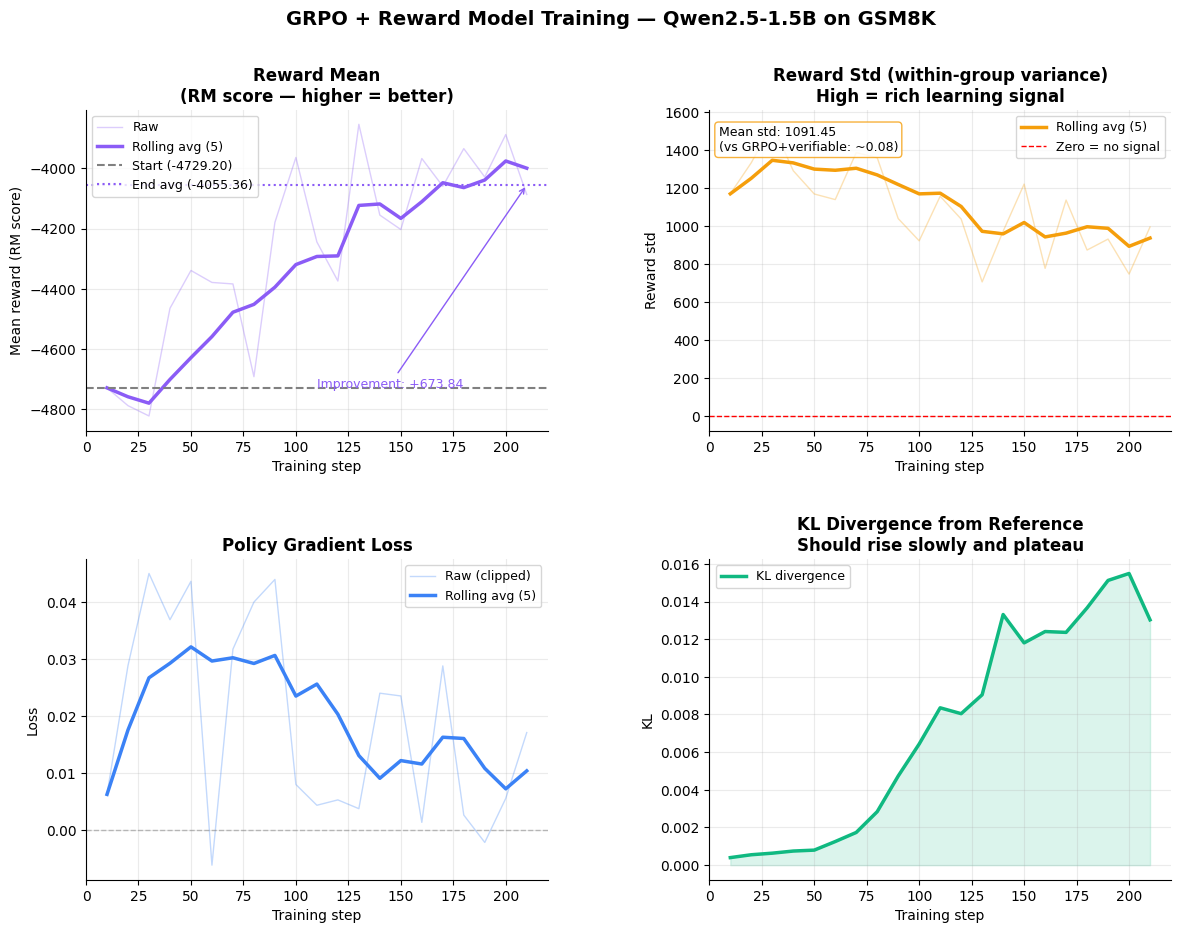

In [38]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── Extract clean history (remove NaN entries) ──
history = [
    h for h in grpo_rm_logger.history
    if not any(np.isnan(v) if isinstance(v, float) else False
               for v in h.values())
    and not np.isnan(h["reward_mean"])
]

steps       = [h["step"]        for h in history]
losses      = [h["loss"]        for h in history]
rewards     = [h["reward_mean"] for h in history]
reward_stds = [h["reward_std"]  for h in history]
kls         = [h["kl"]         for h in history]

def rolling_avg(values, window=5):
    result = []
    for i in range(len(values)):
        start = max(0, i - window + 1)
        result.append(np.mean(values[start:i+1]))
    return result

fig = plt.figure(figsize=(14, 10))
fig.suptitle("GRPO + Reward Model Training — Qwen2.5-1.5B on GSM8K",
             fontsize=14, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# ── Plot 1: Reward mean ──
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(steps, rewards, color="#8B5CF6", alpha=0.3, linewidth=1, label="Raw")
ax1.plot(steps, rolling_avg(rewards, 5), color="#8B5CF6", linewidth=2.5,
         label="Rolling avg (5)")
ax1.axhline(rewards[0], color="gray", linestyle="--", linewidth=1.5,
            label=f"Start ({rewards[0]:.2f})")
ax1.axhline(np.mean(rewards[-10:]), color="#8B5CF6", linestyle=":",
            linewidth=1.5, label=f"End avg ({np.mean(rewards[-10:]):.2f})")
ax1.set_title("Reward Mean\n(RM score — higher = better)", fontweight="bold")
ax1.set_xlabel("Training step")
ax1.set_ylabel("Mean reward (RM score)")
ax1.legend(fontsize=9)
ax1.grid(alpha=0.25)
ax1.spines[["top","right"]].set_visible(False)
# Annotate the improvement
improvement = np.mean(rewards[-10:]) - rewards[0]
ax1.annotate(f"Improvement: {improvement:+.2f}",
             xy=(steps[-1], np.mean(rewards[-10:])),
             xytext=(steps[len(steps)//2], rewards[0] + 0.2),
             fontsize=9, color="#8B5CF6",
             arrowprops=dict(arrowstyle="->", color="#8B5CF6"))

# ── Plot 2: Reward std ──
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(steps, reward_stds, color="#F59E0B", alpha=0.3, linewidth=1)
ax2.plot(steps, rolling_avg(reward_stds, 5), color="#F59E0B", linewidth=2.5,
         label="Rolling avg (5)")
ax2.axhline(0, color="red", linestyle="--", linewidth=1, label="Zero = no signal")
ax2.set_title("Reward Std (within-group variance)\nHigh = rich learning signal",
              fontweight="bold")
ax2.set_xlabel("Training step")
ax2.set_ylabel("Reward std")
ax2.legend(fontsize=9)
ax2.grid(alpha=0.25)
ax2.spines[["top","right"]].set_visible(False)
ax2.text(0.02, 0.95,
         f"Mean std: {np.mean(reward_stds):.2f}\n"
         f"(vs GRPO+verifiable: ~0.08)",
         transform=ax2.transAxes, fontsize=9, va="top",
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                   alpha=0.8, edgecolor="#F59E0B"))

# ── Plot 3: Loss ──
ax3 = fig.add_subplot(gs[1, 0])
clipped = [max(-0.05, min(0.05, l)) for l in losses]
ax3.plot(steps, clipped, color="#3B82F6", alpha=0.3, linewidth=1, label="Raw (clipped)")
ax3.plot(steps, rolling_avg(clipped, 5), color="#3B82F6", linewidth=2.5,
         label="Rolling avg (5)")
ax3.axhline(0, color="gray", linestyle="--", linewidth=1, alpha=0.5)
ax3.set_title("Policy Gradient Loss", fontweight="bold")
ax3.set_xlabel("Training step")
ax3.set_ylabel("Loss")
ax3.legend(fontsize=9)
ax3.grid(alpha=0.25)
ax3.spines[["top","right"]].set_visible(False)

# ── Plot 4: KL divergence ──
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(steps, kls, color="#10B981", linewidth=2.5, label="KL divergence")
ax4.fill_between(steps, 0, kls, color="#10B981", alpha=0.15)
ax4.set_title("KL Divergence from Reference\nShould rise slowly and plateau",
              fontweight="bold")
ax4.set_xlabel("Training step")
ax4.set_ylabel("KL")
ax4.legend(fontsize=9)
ax4.grid(alpha=0.25)
ax4.spines[["top","right"]].set_visible(False)

plt.show()


**As you can see, reward is increasing. This is a good sign that model is learning. Now, let's see the evaluation of GRPO + RM on the eval dataset.**

In [39]:
# ── Evaluate GRPO+RM ──
grpo_rm_acc, _ = evaluate_accuracy(
    grpo_rm_model, eval_ds, label="After GRPO+RM"
)

# ── Save to RESULTS ──
RESULTS["grpo_rm"] = grpo_rm_acc

[After GRPO+RM] Accuracy: 109/200 = 54.5%


**Now you see the beauty of RL :). Even an imperfect RM trained on a very small preference dataset was able to produce a reliable enough signal for GRPO to achieve strong gains.**

---
## Section 5 — DPO: Direct Preference Optimization

Now let's move to DPO. DPO eliminates the need for reward model entirely. DPO directly optimizes the policy using the preference pairs.

### The DPO loss

```
L_DPO = -log σ(
    β × log[π_θ(y_w|x) / π_ref(y_w|x)]
  - β × log[π_θ(y_l|x) / π_ref(y_l|x)]
)
```

Where y_w = chosen (winner), y_l = rejected (loser).

**What this does:** pushes π_θ to assign more probability to chosen responses
and less to rejected responses, relative to π_ref — in a single training step,
no rollouts needed.

### Same preference pairs as the reward model training
We reuse the (prompt, chosen, rejected) dataset we built in Section 3.


In [40]:
# ── Free PPO model ──
del grpo_rm_model
torch.cuda.empty_cache()
print_gpu_memory("after freeing PPO model")

# ── Load fresh model for DPO ──
print("Loading model for DPO...")
dpo_model = load_base_model()
dpo_model = get_peft_model(dpo_model, make_lora_config())
dpo_model.print_trainable_parameters()
print_gpu_memory("after loading DPO model")


[after freeing PPO model] GPU memory: 4.0 / 42.4 GB used
Loading model for DPO...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820
[after loading DPO model] GPU memory: 5.2 / 42.4 GB used


In [41]:

dpo_config = DPOConfig(
    # ── Key hyperparameter: KL constraint strength ──
    # Same β as in the RLHF objective: maximize reward - β × KL(π || π_ref)
    # DPO bakes this directly into the loss — no RL loop needed
    beta=0.1,                    # 0.1 = moderate constraint; try 0.05-0.3
    # ── Training ──
    num_train_epochs=2,
    per_device_train_batch_size=2,   # DPO needs 2x memory vs SFT (chosen + rejected)
    gradient_accumulation_steps=8,   # effective batch = 16
    learning_rate=5e-5,
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,
    bf16=True,
    gradient_checkpointing=True,
    # ── Sequence lengths ──
    # max_prompt_length=256,
    max_length=512,
    # ── Logging ──
    logging_steps=10,
    save_strategy="no",
    report_to="none",
)

dpo_trainer = DPOTrainer(
    model=dpo_model,
    ref_model=None,   # PEFT: uses frozen base weights as reference automatically
    args=dpo_config,
    train_dataset=preference_ds,
    processing_class=tokenizer,
)

print("Starting DPO training...")
dpo_trainer.train()
print("DPO training complete.")
print_gpu_memory("after DPO")


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Adding EOS to train dataset:   0%|          | 0/288 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/288 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151645}.


Starting DPO training...


Step,Training Loss
10,0.684484
20,0.616415
30,0.424934


DPO training complete.
[after DPO] GPU memory: 5.3 / 42.4 GB used


**We stopped only at 40 training steps. We could have trained longer for better results. But every 40 steps is be as good as SFT :). This is the beauty of RL.**

In [42]:
# ── Evaluate DPO ──
dpo_acc, _ = evaluate_accuracy(dpo_model, eval_ds, label="After DPO")
RESULTS["dpo"] = dpo_acc
print(f"Improvement over baseline : {dpo_acc - RESULTS['baseline']:+.1%}")
print(f"Improvement over SFT      : {dpo_acc - RESULTS['sft']:+.1%}")


[After DPO] Accuracy: 84/200 = 42.0%
Improvement over baseline : -0.5%
Improvement over SFT      : +0.0%


In [45]:
RESULTS

{'baseline': 0.425, 'sft': 0.42, 'grpo_rm': 0.545, 'dpo': 0.42}

---
## Section 6 — GRPO with verifiable rewards (RLVR)

In GRPO + RM, we had to train a seperate NN for reward model. RLVR uses a hard coded reward function, i.e., no need for a seperate NN. This is what was used in DeepSeek used to train R1. The reward here is verifiable
(correct answer = 1, wrong = 0).


In [46]:
# ── Free DPO model ──
del dpo_model
torch.cuda.empty_cache()
print_gpu_memory("after freeing DPO model")

# ── Load fresh model for GRPO ──
print("Loading model for GRPO...")
grpo_model = load_base_model()
print_gpu_memory("after loading GRPO model")


[after freeing DPO model] GPU memory: 5.3 / 42.4 GB used
Loading model for GRPO...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

[after loading GRPO model] GPU memory: 6.5 / 42.4 GB used


**Let's now define the hard coded verifiable reward function. We will only count on correctness in this section. We can improve this later (next section)**

In [47]:
# ── Verifiable reward function for GRPO ──
def grpo_reward_fn(completions, ground_truth, **kwargs):
    """
    Called by GRPOTrainer after sampling G completions per prompt.

    Args:
        completions: list of G generated strings for this prompt
        ground_truth: the correct answer string

    Returns:
        list of G scalar rewards (1.0 = correct, 0.0 = wrong)

    This is RLVR: a deterministic rule-based checker.
    Cannot be reward-hacked — either the number matches or it doesn't.
    """
    rewards = []
    for completion, gt in zip(completions, ground_truth):
        predicted = extract_predicted_answer(completion)
        reward = 1.0 if (predicted is not None and predicted == gt) else 0.0
        rewards.append(reward)

    return rewards

# ── Format dataset for GRPO ──
# GRPOTrainer expects 'prompt' column and any extra columns passed to reward_fn
def format_grpo(item):
    return {
        "prompt"        : item["prompt"],
        "ground_truth"  : item["ground_truth"],
    }

grpo_train_ds = train_ds.map(format_grpo, remove_columns=[
    c for c in train_ds.column_names if c not in ["prompt","ground_truth"]
])


Map:   0%|          | 0/500 [00:00<?, ? examples/s]

In [48]:
grpo_config = GRPOConfig(
    # ── Core GRPO hyperparameters ──
    num_generations=8,           # G: number of responses sampled per prompt
                                # More = better advantage estimate, but slower
    # ── KL constraint ──
    beta=0.04,                # keeps policy from drifting too far from reference
    # ── Training ──
    learning_rate=1e-5,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,
    num_train_epochs=2,
    max_steps=300,
    # ── Generation settings ──
    max_completion_length=256,
    temperature=1.4,             # sampling temperature for rollouts
    # ── Logging ──
    logging_steps=10,
    save_strategy="no",
    bf16=True,
    report_to="tensorboard",
)

grpo_trainer = GRPOTrainer(
    model=grpo_model,
    args=grpo_config,
    reward_funcs=grpo_reward_fn,
    train_dataset=grpo_train_ds,
    processing_class=tokenizer,
    peft_config=make_lora_config(),
    callbacks=[grpo_logger],
)

print("Starting GRPO training...")
grpo_trainer.train()
print("GRPO training complete.")
print_gpu_memory("after GRPO")


[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151645}.


Starting GRPO training...


Step,Training Loss
10,0.016029
20,0.003228
30,0.005716
40,0.000018
50,0.007248
60,0.001633
70,-0.003505
80,0.000022
90,0.000023
100,0.000085


Step   10 | loss=0.016029 | reward_mean=0.0125 | reward_std=0.0500 | kl=0.000358
Step   20 | loss=0.003228 | reward_mean=0.0312 | reward_std=0.0903 | kl=0.000398
Step   30 | loss=0.005716 | reward_mean=0.0187 | reward_std=0.0403 | kl=0.000416
Step   40 | loss=0.000018 | reward_mean=0.0000 | reward_std=0.0000 | kl=0.000449
Step   50 | loss=0.007248 | reward_mean=0.0250 | reward_std=0.0842 | kl=0.000469
Step   60 | loss=0.001633 | reward_mean=0.0688 | reward_std=0.2039 | kl=0.000512
Step   70 | loss=-0.003505 | reward_mean=0.0312 | reward_std=0.0903 | kl=0.000511
Step   80 | loss=0.000022 | reward_mean=0.0000 | reward_std=0.0000 | kl=0.000553
Step   90 | loss=0.000023 | reward_mean=0.0125 | reward_std=0.0500 | kl=0.000584
Step  100 | loss=0.000085 | reward_mean=0.0187 | reward_std=0.0750 | kl=0.000604
Step  110 | loss=0.008142 | reward_mean=0.0187 | reward_std=0.0592 | kl=0.000620
Step  120 | loss=0.000027 | reward_mean=0.0250 | reward_std=0.1000 | kl=0.000673
Step  130 | loss=0.000027 |

**Let's plot the reward to make sure we have an increasing reward trend.**

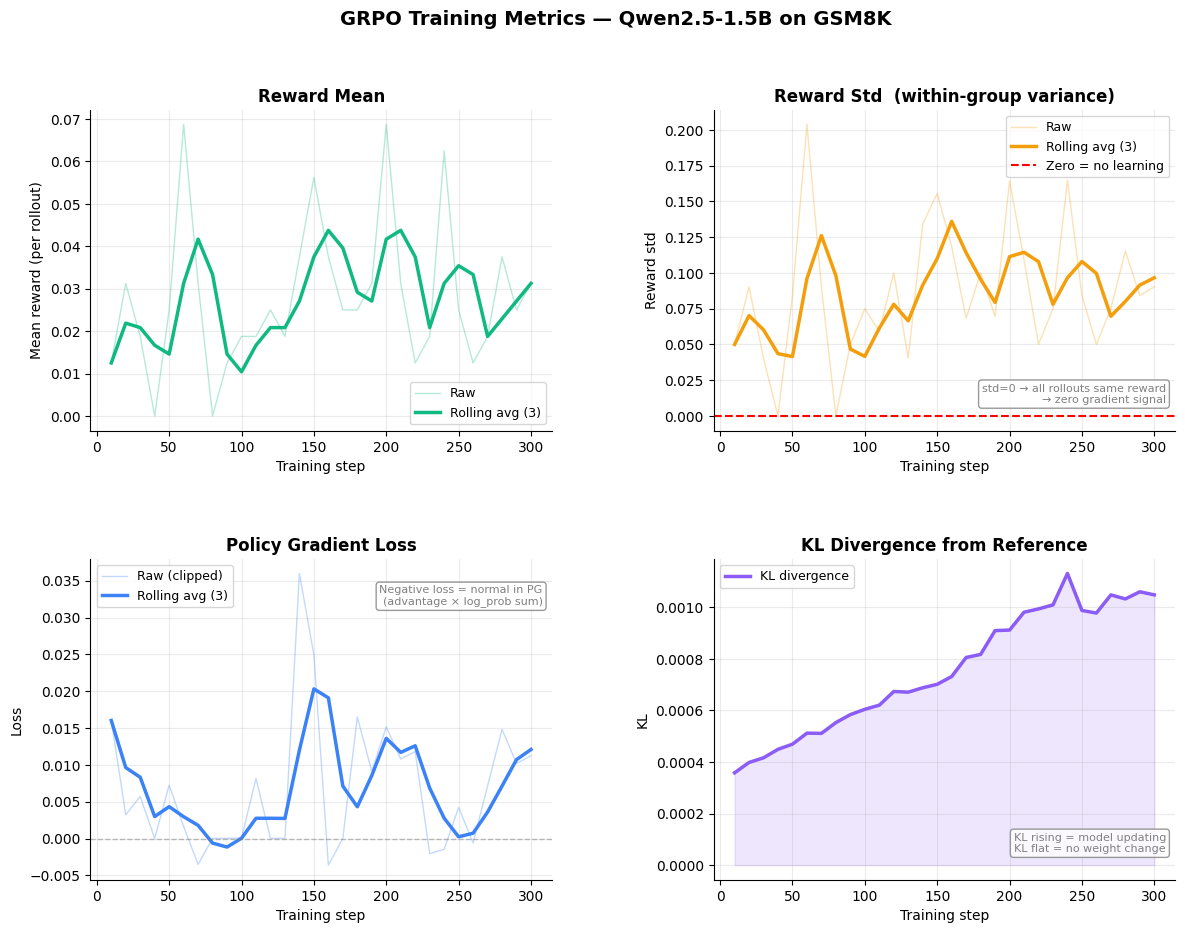

In [49]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── Extract history from logger ──
history = [h for h in grpo_logger.history if not any(
    np.isnan(v) for v in [h['reward_mean'], h['reward_std'], h['kl']]
)]

steps       = [h["step"]        for h in history]
losses      = [h["loss"]        for h in history]
rewards     = [h["reward_mean"] for h in history]
reward_stds = [h["reward_std"]  for h in history]
kls         = [h["kl"]         for h in history]

# ── Rolling average helper ──
def rolling_avg(values, window=3):
    result = []
    for i in range(len(values)):
        start = max(0, i - window + 1)
        result.append(np.mean(values[start:i+1]))
    return result

fig = plt.figure(figsize=(14, 10))
fig.suptitle("GRPO Training Metrics — Qwen2.5-1.5B on GSM8K",
             fontsize=14, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# ── Plot 1: Reward mean ──
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(steps, rewards, color="#10B981", alpha=0.3, linewidth=1, label="Raw")
ax1.plot(steps, rolling_avg(rewards), color="#10B981", linewidth=2.5, label="Rolling avg (3)")
ax1.set_title("Reward Mean", fontweight="bold")
ax1.set_xlabel("Training step")
ax1.set_ylabel("Mean reward (per rollout)")
ax1.legend(fontsize=9)
ax1.grid(alpha=0.25)
ax1.spines[["top","right"]].set_visible(False)

# ── Plot 2: Reward std ──
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(steps, reward_stds, color="#F59E0B", alpha=0.3, linewidth=1, label="Raw")
ax2.plot(steps, rolling_avg(reward_stds), color="#F59E0B", linewidth=2.5, label="Rolling avg (3)")
ax2.axhline(0, color="red", linestyle="--", linewidth=1.5, label="Zero = no learning")
ax2.set_title("Reward Std  (within-group variance)", fontweight="bold")
ax2.set_xlabel("Training step")
ax2.set_ylabel("Reward std")
ax2.legend(fontsize=9)
ax2.grid(alpha=0.25)
ax2.spines[["top","right"]].set_visible(False)

# Add annotation explaining what zero means
ax2.text(0.98, 0.08,
         "std=0 → all rollouts same reward\n→ zero gradient signal",
         transform=ax2.transAxes, fontsize=8, color="gray",
         ha="right", va="bottom",
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                   alpha=0.8, edgecolor="gray"))

# ── Plot 3: Loss ──
ax3 = fig.add_subplot(gs[1, 0])
# Clip extreme values for visibility
clipped_loss = [max(-0.05, min(0.1, l)) for l in losses]
ax3.plot(steps, clipped_loss, color="#3B82F6", alpha=0.3, linewidth=1, label="Raw (clipped)")
ax3.plot(steps, rolling_avg(clipped_loss), color="#3B82F6", linewidth=2.5, label="Rolling avg (3)")
ax3.axhline(0, color="gray", linestyle="--", linewidth=1, alpha=0.5)
ax3.set_title("Policy Gradient Loss", fontweight="bold")
ax3.set_xlabel("Training step")
ax3.set_ylabel("Loss")
ax3.legend(fontsize=9)
ax3.grid(alpha=0.25)
ax3.spines[["top","right"]].set_visible(False)
ax3.text(0.98, 0.92,
         "Negative loss = normal in PG\n(advantage × log_prob sum)",
         transform=ax3.transAxes, fontsize=8, color="gray",
         ha="right", va="top",
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                   alpha=0.8, edgecolor="gray"))

# ── Plot 4: KL divergence ──
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(steps, kls, color="#8B5CF6", linewidth=2.5, label="KL divergence")
ax4.fill_between(steps, 0, kls, color="#8B5CF6", alpha=0.15)
ax4.set_title("KL Divergence from Reference", fontweight="bold")
ax4.set_xlabel("Training step")
ax4.set_ylabel("KL")
ax4.legend(fontsize=9)
ax4.grid(alpha=0.25)
ax4.spines[["top","right"]].set_visible(False)
ax4.text(0.98, 0.08,
         "KL rising = model updating\nKL flat = no weight change",
         transform=ax4.transAxes, fontsize=8, color="gray",
         ha="right", va="bottom",
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                   alpha=0.8, edgecolor="gray"))

plt.show()

**Since reward is binary, either 1 (correct) or 0 (incorrect), it is hard to see a trend in the reward. However, the KL diveregnce is increasing == we are deviating from reference model == indication of learning. Let's evalue GRPO RLVR.**

In [50]:
# ── Evaluate GRPO ──
grpo_acc, _ = evaluate_accuracy(grpo_model, eval_ds, label="After GRPO")
RESULTS["grpo"] = grpo_acc
print(f"Improvement over baseline : {grpo_acc - RESULTS['baseline']:+.1%}")
print(f"Improvement over SFT      : {grpo_acc - RESULTS['sft']:+.1%}")


[After GRPO] Accuracy: 90/200 = 45.0%
Improvement over baseline : +2.5%
Improvement over SFT      : +3.0%


**As you can see, even with a binary simple reward, we were able to beat SFT and baseline models.**

**Now, let's try to improve RLVR with adding more rich reward**

---
## Section 7 — RLVR: Improving the reward

### The richer RLVR reward
To improve the reward, we can add +ve reward if the model style was good, e.g., shows reasoning steps.

```python
def rlvr_reward(response, ground_truth):
    # Correctness reward: main signal
    answer_correct = extract_answer(response) == ground_truth  # 0 or 1
    
    # Format reward: bonus for showing reasoning steps
    has_reasoning = "<think>" in response or len(response.split("\n")) > 3
    
    # Combined reward (correctness dominates)
    return answer_correct * 1.0 + has_reasoning * 0.1
```

The format reward encourages the model to develop chain-of-thought reasoning
— this is what causes the spontaneous "aha moment" behavior observed in R1.


In [53]:
# ── Free GRPO model ──
del grpo_model
torch.cuda.empty_cache()
print_gpu_memory("after freeing GRPO model")

# ── Load fresh model for RLVR ──
print("Loading model for RLVR...")
rlvr_model = load_base_model()
print_gpu_memory("after loading RLVR model")


[after freeing GRPO model] GPU memory: 7.7 / 42.4 GB used
Loading model for RLVR...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

[after loading RLVR model] GPU memory: 8.9 / 42.4 GB used


**Let's define our new reward function.**

In [54]:
def rlvr_reward_fn(completions, ground_truth, **kwargs):
    """
    RLVR reward function with two components:

    1. CORRECTNESS (1.0): Did the model get the right answer?
       This is the primary signal — no partial credit.

    2. FORMAT (0.1 bonus): Did the model show its reasoning?
       - Presence of step-by-step arithmetic (multiple lines)
       - Presence of <think> tags or similar reasoning markers

    Why the format reward?
    - Without it, the model might learn to guess answers without reasoning
    - With it, the model is incentivized to develop chain-of-thought
    - This is what causes 'emergent reasoning' in models like DeepSeek-R1

    Note: correctness reward (1.0) >> format reward (0.1)
    The format bonus is a soft nudge, not the primary training signal.
    """
    rewards = []
    for completion, gt in zip(completions, ground_truth):
        # ── Component 1: Correctness ──
        predicted = extract_predicted_answer(completion)
        correctness = 1.0 if (predicted is not None and predicted == gt) else 0.0

        # ── Component 2: Format / reasoning quality ──
        # Check for multi-step reasoning (not just a one-liner answer)
        lines = [l.strip() for l in completion.split("\n") if l.strip()]
        has_multi_step = len(lines) >= 3

        # Check for explicit arithmetic steps (e.g., "= 24", "÷ 2", "× 48")
        has_arithmetic = bool(re.search(r'[=÷×+\-]\s*\d+', completion))

        # Check for self-checking language (emergent in R1)
        has_selfcheck = any(phrase in completion.lower() for phrase in
                           ["wait", "let me check", "let me verify",
                            "actually", "so the answer is"])

        format_bonus = 0.0
        if has_multi_step:   format_bonus += 0.05
        if has_arithmetic:   format_bonus += 0.03
        if has_selfcheck:    format_bonus += 0.02   # rare but rewarded

        total_reward = correctness + format_bonus
        rewards.append(total_reward)

    return rewards

# ── Reuse same dataset format as GRPO ──
rlvr_train_ds = grpo_train_ds  # identical format: prompt + ground_truth


In [55]:

rlvr_config = GRPOConfig(       # RLVR uses GRPO algorithm, different reward function
    num_generations=8,
    beta=0.04,
    learning_rate=1e-5,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,
    num_train_epochs=2,
    max_steps=200,
    max_completion_length=300,          # slightly longer to allow more reasoning
    temperature=0.9,
    logging_steps=10,
    save_strategy="no",
    bf16=True,
    report_to="none",
)

rlvr_trainer = GRPOTrainer(
    model=rlvr_model,
    args=rlvr_config,
    reward_funcs=rlvr_reward_fn,    # richer reward vs GRPO section
    train_dataset=rlvr_train_ds,
    processing_class=tokenizer,
    peft_config=make_lora_config()
)

print("Starting RLVR training...")
rlvr_trainer.train()
print("RLVR training complete.")
print_gpu_memory("after RLVR")


[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151645}.


Starting RLVR training...


Step,Training Loss
10,-0.000799
20,-0.014269
30,-0.007426
40,0.031978
50,0.012958
60,0.036086
70,0.006363
80,-0.000360
90,0.041093
100,0.008448


RLVR training complete.
[after RLVR] GPU memory: 7.7 / 42.4 GB used


In [56]:
# ── Evaluate RLVR ──
rlvr_acc, rlvr_results = evaluate_accuracy(rlvr_model, eval_ds, label="After RLVR")
RESULTS["rlvr"] = rlvr_acc
print(f"Improvement over baseline : {rlvr_acc - RESULTS['baseline']:+.1%}")
print(f"Improvement over SFT      : {rlvr_acc - RESULTS['sft']:+.1%}")



[After RLVR] Accuracy: 96/200 = 48.0%
Improvement over baseline : +5.5%
Improvement over SFT      : +6.0%


**As you can see, the richer reward improved the performance even more :)**

In [57]:
# ── Check if self-checking behavior emerged ──
print("\n--- Checking for emergent reasoning behaviors ---")
selfcheck_count = sum(
    1 for r in rlvr_results
    if any(p in r["generated"].lower() for p in ["wait","let me check","actually","let me verify"])
)
print(f"Responses with self-checking language: {selfcheck_count}/{len(rlvr_results)} ({selfcheck_count/len(rlvr_results):.0%})")



--- Checking for emergent reasoning behaviors ---
Responses with self-checking language: 5/200 (2%)


---
## Section 8 — Comparison: All Methods Side by Side

Now let's put all results together and understand what each method contributed.


In [58]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Results summary ──
print("=" * 55)
print(f"{'Method':<20} {'Accuracy':>10} {'vs Baseline':>12}")
print("=" * 55)
for method, acc in RESULTS.items():
    delta = acc - RESULTS["baseline"] if method != "baseline" else 0.0
    marker = "★" if acc == max(RESULTS.values()) else " "
    print(f"{marker} {method:<19} {acc:>9.1%} {delta:>+11.1%}")
print("=" * 55)
print(f"  Best method: {max(RESULTS, key=RESULTS.get).upper()}")


Method                 Accuracy  vs Baseline
  baseline                42.5%       +0.0%
  sft                     42.0%       -0.5%
★ grpo_rm                 54.5%      +12.0%
  dpo                     42.0%       -0.5%
  grpo                    45.0%       +2.5%
  rlvr                    48.0%       +5.5%
  Best method: GRPO_RM


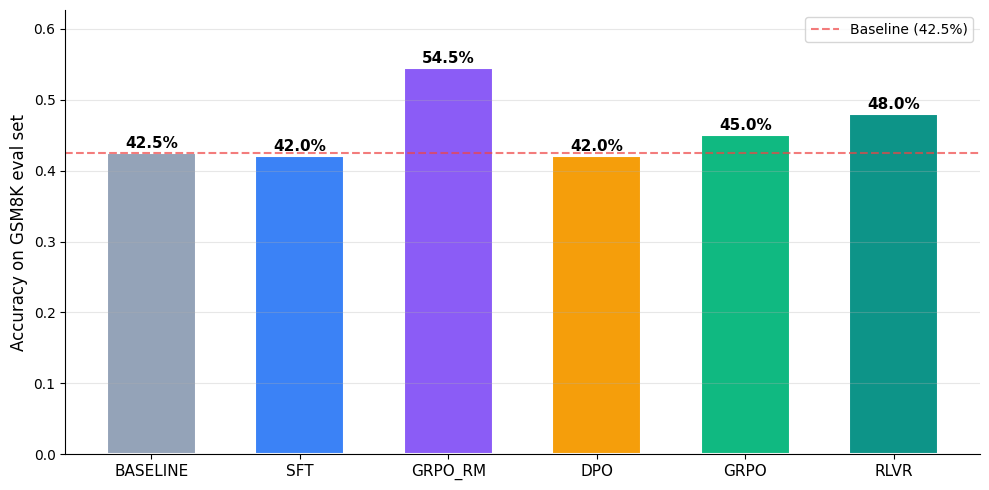

In [59]:
# ── Bar chart ──
fig, ax = plt.subplots(figsize=(10, 5))

methods = list(RESULTS.keys())
accs    = [RESULTS[m] for m in methods]
colors  = ["#94A3B8", "#3B82F6", "#8B5CF6", "#F59E0B", "#10B981", "#0D9488"]

bars = ax.bar(methods, accs, color=colors, width=0.6, edgecolor="white", linewidth=1.5)

# Baseline reference line
ax.axhline(RESULTS["baseline"], color="#EF4444", linestyle="--",
           linewidth=1.5, alpha=0.7, label=f"Baseline ({RESULTS['baseline']:.1%})")

# Value labels on bars
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{acc:.1%}", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_ylim(0, min(1.0, max(accs) * 1.15))
ax.set_ylabel("Accuracy on GSM8K eval set", fontsize=12)
# ax.set_title("GSM8K Accuracy: Qwen2.5-1.5B-Instruct
# Baseline → SFT → Reward Model → PPO / DPO / GRPO / RLVR",
#              fontsize=13, fontweight="bold")
ax.set_xticklabels([m.upper() for m in methods], fontsize=11)
ax.legend(fontsize=10)
ax.spines[["top","right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()
